In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
mu_m = 0.9       # h^-1
K_S = 0.21      # g/L
K_I = 1.5       # g/L
Y_XS = 0.6      # g/g
K_CL = 0.2      # mg/L
Y_OS = 160      # mg/g
M = 0.0314
V_L = 90        # L
G = 5000        # L/h
eps = 0.2
V_G = eps * V_L

C_Li = 6        # mg/L
C_Gi = 250      # mg/L
S_i = 30        # g/L

# Initial conditions
y0 = [1, 0, 6, 250]   # X, S, C_L, C_G

CL_limit = 3 * K_CL   # oxygen limitation threshold


def growth_rate(S, CL):
    return mu_m * S / (K_S + S + S**2 / K_I) * CL / (K_CL + CL)


def system(t, y, F, KLa):
    X, S, CL, CG = y
    
    mu = growth_rate(S, CL)
    CL_star = M * CG
    
    dXdt = -(F / V_L) * X + mu * X
    
    dSdt = (F / V_L) * (S_i - S) - (1 / Y_XS) * mu * X
    
    dCLdt = (F / V_L) * (C_Li - CL) - (Y_OS / Y_XS) * mu * X + KLa * (CL_star - CL)
    
    dCGdt = (G / V_G) * (C_Gi - CG) - KLa * (V_L / V_G) * (CL_star - CL)
    
    return [dXdt, dSdt, dCLdt, dCGdt]


def simulate(F, KLa, t_end=500):
    sol = solve_ivp(system, [0, t_end], y0, args=(F, KLa), method="BDF", rtol=1e-6, atol=1e-6)
    return sol


def is_not_oxygen_limited(F, KLa):
    sol = simulate(F, KLa)
    CL = sol.y[2]
    return np.min(CL) > CL_limit, np.min(CL), sol


F_values = np.linspace(6.5, 10, 8)
KLa_values = []

for F in F_values:
    for KLa in np.linspace(1, 50, 1000):
        ok, CL_min, sol = is_not_oxygen_limited(F, KLa)
        if ok:
            KLa_values.append(KLa)
            print(f"F = {F:.2f} L/h, minimum KLa = {KLa:.2f} h^-1, min CL = {CL_min:.3f} mg/L")
            break

F = 6.50 L/h, minimum KLa = 16.40 h^-1, min CL = 0.602 mg/L
F = 7.00 L/h, minimum KLa = 16.06 h^-1, min CL = 0.604 mg/L
F = 7.50 L/h, minimum KLa = 15.76 h^-1, min CL = 0.601 mg/L
F = 8.00 L/h, minimum KLa = 15.57 h^-1, min CL = 0.600 mg/L
F = 8.50 L/h, minimum KLa = 15.42 h^-1, min CL = 0.601 mg/L
F = 9.00 L/h, minimum KLa = 15.32 h^-1, min CL = 0.604 mg/L
F = 9.50 L/h, minimum KLa = 15.18 h^-1, min CL = 0.600 mg/L
F = 10.00 L/h, minimum KLa = 15.13 h^-1, min CL = 0.605 mg/L


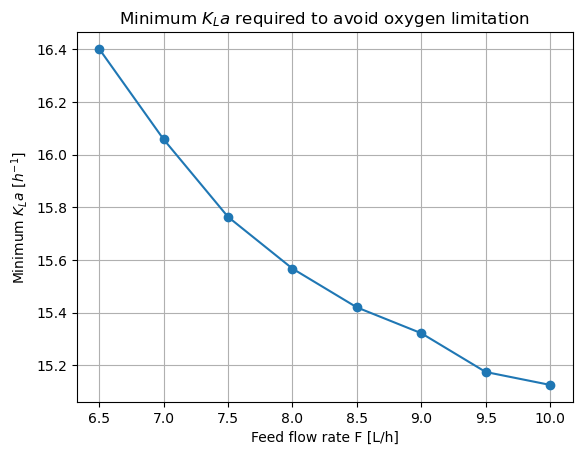

In [5]:
plt.figure()
plt.plot(F_values, KLa_values, marker="o")
plt.xlabel("Feed flow rate F [L/h]")
plt.ylabel(r"Minimum $K_La$ [$h^{-1}$]")
plt.title(r"Minimum $K_La$ required to avoid oxygen limitation")
plt.grid(True)
plt.show()

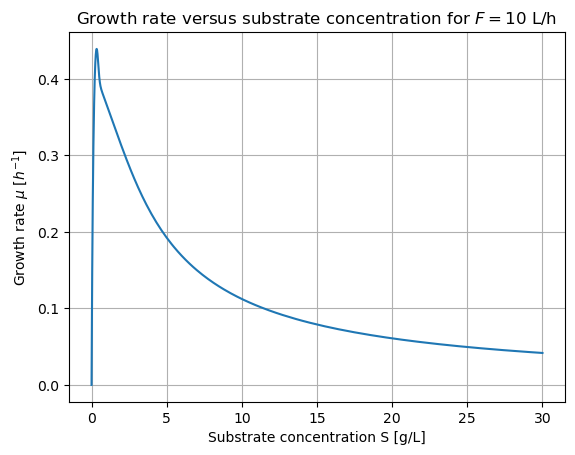

In [6]:
F_target = 10
KLa_target = KLa_values[-1]

sol = simulate(F_target, KLa_target)

X = sol.y[0]
S = sol.y[1]
CL = sol.y[2]

mu = growth_rate(S, CL)

idx = np.argsort(S)

plt.figure()
plt.plot(S[idx], mu[idx])
plt.xlabel("Substrate concentration S [g/L]")
plt.ylabel(r"Growth rate $\mu$ [$h^{-1}$]")
plt.title(r"Growth rate versus substrate concentration for $F=10$ L/h")
plt.grid(True)
plt.show()